<h1><center>"Multi-Table E-Commerce European Fashion"</center></h1>

### **1. Importación librerías**

In [9]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Cargar base de datos desde SQL**

In [12]:
user = "postgres"
password = quote_plus("*****") # ***** -> mi contraseña
host = "localhost"
port = "5432"
database = "01_portfolio_ecommerce"

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

### **3. Definir tabla a analizar**

In [13]:
e_commerce = pd.read_sql("SELECT * FROM sales_analysis", engine)

e_commerce.head()

,sale_id,sale_date,sale_channel,sale_discounted,total_amount,sale_country,customer_id,age_range,signup_date,item_id,...,catalog_price,cost_price,gender,campaign_id,campaign_name,campaign_start_date,campaign_end_date,campaign_channel,discount_type,discount_value
0,658,2025-06-16,App Mobile,False,374.25,Portugal,835,46-55,2025-04-26,2270,...,81.80,45.12,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0
1,336,2025-06-17,E-commerce,False,536.47,France,790,16-25,2025-04-26,1170,...,81.79,35.02,Female,6,June Price Drop,2025-06-01,2025-06-09,Website Banner,Percentage,10.0
2,1255,2025-04-16,App Mobile,False,104.81,Germany,464,36-45,2025-04-14,2496,...,80.76,51.01,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0
3,331,2025-06-05,App Mobile,False,263.87,Italy,100,26-35,2025-01-30,1273,...,78.52,41.48,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0
4,1079,2025-06-15,App Mobile,False,173.84,Germany,837,46-55,2025-03-02,1829,...,78.52,41.48,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0


### **4. Limpieza y manipulación de datos**

#### **4.1. Explorar el dataset**

In [14]:
# Revisión del tamaño del dataset, nombre de las columnas, datos nulos y tipo de datos
e_commerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2411 entries, 0 to 2410
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              2411 non-null   int64  
 1   sale_date            2411 non-null   object 
 2   sale_channel         2411 non-null   object 
 3   sale_discounted      2411 non-null   bool   
 4   total_amount         2411 non-null   float64
 5   sale_country         2411 non-null   object 
 6   customer_id          2411 non-null   int64  
 7   age_range            2411 non-null   object 
 8   signup_date          2411 non-null   object 
 9   item_id              2411 non-null   int64  
 10  product_id           2411 non-null   int64  
 11  quantity             2411 non-null   int64  
 12  original_price       2411 non-null   float64
 13  unit_price           2411 non-null   float64
 14  discount_applied     2411 non-null   float64
 15  discount_percent     2411 non-null   f

#### Se tiene una tabla de 20411 filas y 34 columnas. Estas últimas tienen nombres adecuados y sin repetición, mientras que, por otro lado, no hay datos nulos. Se observa que existen columnas con tipos de datos inadecuados que hay que corregir. Estas son: "sale_date", "signup_date", "campaign_start_date" y "campaign_end_date"; todas tienen el tipo de dato "object" que hay que convertir a "datetime"

#### **4.2. Conversión de tipos de datos**

In [15]:
# Definir columnas a corregir el dtype
cols = ["sale_date", "signup_date", "campaign_start_date", "campaign_end_date"]

# Conversión de tipo de datos a "datetime"
e_commerce[cols] = e_commerce[cols].apply(pd.to_datetime, errors = "coerce")

# Verificar cambios
print(e_commerce[cols].dtypes)

sale_date              datetime64[ns]
signup_date            datetime64[ns]
campaign_start_date    datetime64[ns]
campaign_end_date      datetime64[ns]
dtype: object


#### **4.3. Observar duplicados**

In [16]:
# Búsqueda de duplicados exactos
e_commerce[e_commerce.duplicated()]

,sale_id,sale_date,sale_channel,sale_discounted,total_amount,sale_country,customer_id,age_range,signup_date,item_id,...,catalog_price,cost_price,gender,campaign_id,campaign_name,campaign_start_date,campaign_end_date,campaign_channel,discount_type,discount_value


#### El dataset no tiene duplicados

### **5. Análisis exploratorio**

#### **5.1. Definir variables derivadas para el análisis**

In [17]:
# Generar variables
e_commerce["year_month"] = e_commerce["sale_date"].dt.to_period("M").astype(str) # Extraer mes
e_commerce["profit_unit"] = e_commerce["unit_price"] - e_commerce["cost_price"] # Ganancia por unidad de producto
e_commerce["profit_total"] = e_commerce["profit_unit"] * e_commerce["quantity"] # Ganancia total
e_commerce["discount_rate_calc"] = np.where(e_commerce["original_price"] > 0, # Proporción descuento
                                (e_commerce["original_price"] - e_commerce["unit_price"]) / e_commerce["original_price"], 0)

#### **5.2. Definir KPIs**

In [18]:
# Definir KPIs generales
kpis = {
    "rows": len(e_commerce), # Número total de filas
    "unique_sales": e_commerce['sale_id'].nunique(), # Cantidad de ventas únicas
    "unique_customers": e_commerce["customer_id"].nunique(), # Cantidad de clientes únicos
    "unique_products": e_commerce["product_id"].nunique(), # Cantidad de productos únicos
    "revenue_items": round(e_commerce["item_total"].sum(), 2), # Ingresos totales por ítems vendidos
    "estimated_profit": round(e_commerce["profit_total"].sum(), 2), # Ganancia estimada total
    "avg_order_value": round(e_commerce.groupby("sale_id")["item_total"].sum().mean(), 2) # Ticket promedio por orden
}

# Observar KPIs
kpis

{'rows': 2411,
 'unique_sales': 905,
 'unique_customers': 580,
 'unique_products': 499,
 'revenue_items': np.float64(336230.42),
 'estimated_profit': np.float64(143990.95),
 'avg_order_value': np.float64(371.53)}

#### **5.3. Calcular Revenue por Canal**

In [19]:
# Generar nuevo DataFrame con variables de interés
sales_by_channel = (
    e_commerce.groupby("sale_channel", as_index = False).agg(
        revenue = ("item_total", "sum"),
        units_sold = ("quantity", "sum"),
        orders = ("sale_id", "nunique")
    )
    .sort_values("revenue", ascending = False)
)

# Observar DataFrame
sales_by_channel

,sale_channel,revenue,units_sold,orders
1,E-commerce,174000.54,3561,473
0,App Mobile,162229.88,3476,432


#### **5.4. Calcular Revenue por País**

In [20]:
# Generar nuevo DataFrame con variables de interés
sales_by_country = (
    e_commerce.groupby("sale_country", as_index = False).agg(
        revenue = ("item_total", "sum"),
        orders = ("sale_id", "nunique"),
        customers = ("customer_id", "nunique")
    )
    .sort_values("revenue", ascending = False)
)

# Observar DataFrame
sales_by_country

,sale_country,revenue,orders,customers
1,Germany,77286.07,212,145
0,France,74332.98,199,125
2,Italy,62609.38,170,103
3,Netherlands,48363.94,131,84
5,Spain,42613.30,113,75
4,Portugal,31024.75,80,48


#### **5.5. Calcular Revenue por Categorías**

In [21]:
# Generar nuevo DataFrame con variables de interés
top_categories = (
    e_commerce.groupby("category", as_index = False).agg(
        revenue = ("item_total", "sum"),
        units_sold = ("quantity", "sum"),
        estimated_profit = ("profit_total", "sum")
    )
    .sort_values("revenue", ascending = False)
)

# Observar DataFrame
top_categories

,category,revenue,units_sold,estimated_profit
4,T-Shirts,72969.06,1523,31568.67
2,Shoes,71850.36,1448,31013.63
0,Dresses,71432.39,1537,30583.95
3,Sleepwear,64384.25,1422,26327.49
1,Pants,55594.36,1107,24497.21


#### **5.6. Calcular Revenue por Mes**

In [22]:
# Generar nuevo DataFrame con variables de interés
monthly_sales = (
    e_commerce.groupby("year_month", as_index = False).agg(
        revenue = ("item_total", "sum"),
        units_sold = ("quantity", "sum"),
        estimated_profit = ("profit_total", "sum")
    )
    .sort_values("revenue", ascending = False)
)

# Observar DataFrame
monthly_sales

,year_month,revenue,units_sold,estimated_profit
1,2025-05,152027.39,3306,62553.02
0,2025-04,134456.64,2713,59532.76
2,2025-06,49746.39,1018,21905.17


#### **5.7. Revenue de Ítems con Descuento vs. No Descuento** 

In [23]:
# Cálculos asociados de productos "descuento vs. no descuento"
discount_analysis = (
    e_commerce.groupby("item_discounted", as_index = False).agg(
        revenue = ("item_total", "sum"),
        avg_discount_pct = ("discount_percent", "mean"),
        units_sold = ("quantity", "sum"),
        estimated_profit = ("profit_total", "sum")
    )
)

# Observar DataFrame
discount_analysis

,item_discounted,revenue,avg_discount_pct,units_sold,estimated_profit
0,False,300663.83,0.000000,6082,134898.76
1,True,35566.59,24.684211,955,9092.19


#### **5.8. Calcular Revenue por Rango Etario**

In [24]:
# Generar nuevo DataFrame con variables de interés
age_analysis = (
    e_commerce.groupby("age_range", as_index = False).agg(
        revenue = ("item_total", "sum"),
        orders = ("sale_id", "nunique"),
        customers = ("customer_id", "nunique")
    )
    .sort_values("age_range")
)

# Observar DataFrame
age_analysis

,age_range,revenue,orders,customers
0,16-25,68201.00,181,116
1,26-35,72034.86,189,121
2,36-45,71131.78,188,122
3,46-55,64715.51,176,111
4,56-65,60147.27,171,110


### **6. Gráficos**

In [25]:
sns.set_style("whitegrid") # Definir por defecto el fondo en grilla en gráficos

#### **6.1. Revenue por Canal de Venta**

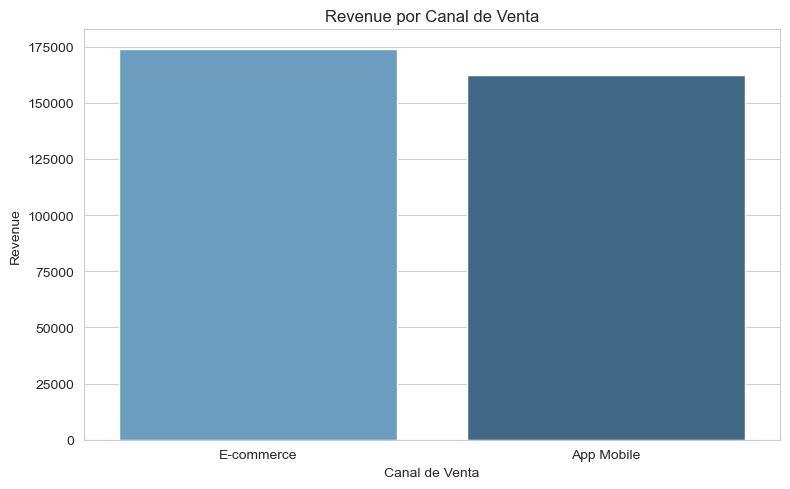

In [26]:
plt.figure(figsize = (8,5))
sns.barplot(data = sales_by_channel, x = "sale_channel", y = "revenue", hue = "sale_channel", palette = "Blues_d", legend = False)
plt.title("Revenue por Canal de Venta")
plt.xlabel("Canal de Venta")
plt.ylabel("Revenue")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

**Insight principal:** E-commerce (página web) lidera con el ≈52% del revenue total, pero App Mobile (aplicación telefónica) representa un ≈48% sólido.

**Recomiendación:** Priorizar web, pero no descuidar app.

**Detalles:**
- E-commerce: 174,000.54 € (51.8% del total)
- App Mobile: 162,229.88 € (48.2% del total)

#### **6.2. Revenue por País**

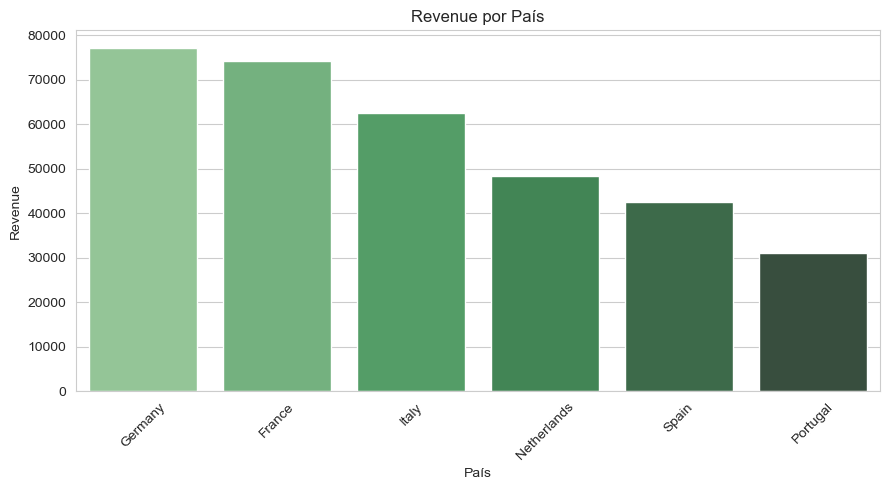

In [27]:
plt.figure(figsize = (9,5))
sns.barplot(data = sales_by_country, x = "sale_country", y = "revenue", hue = "sale_country", palette = "Greens_d", legend = False)
plt.title("Revenue por País")
plt.xlabel("País")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Insight principal:** Alemania lidera con 23% del revenue, seguida por Francia (22.1%) e Italia (18.6%). Estos países concentran más del 50% de los ingresos totales (63.7%).

**Recomendación:** Replicar estrategias de ventas exitosas de Alemania, Francia e Italia en Países Bajos, España y Portugal.

**Detalles:**
- Alemania: 77,286.07 € (23.0% del total)
- Francia: 74,332.98 € (22.1% del total)
- Italia: 62,609.38 € (18.6% del total)
- Otros países: 36.3%

#### **6.3. Revenue por Categorías**

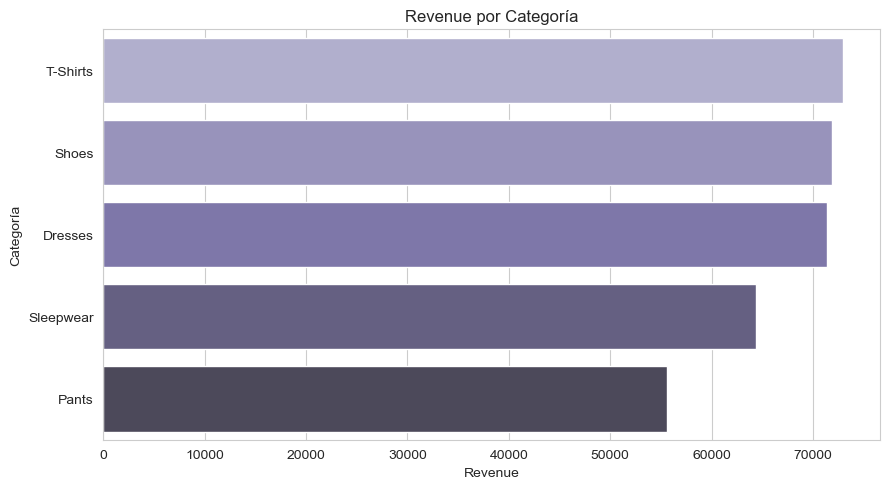

In [28]:
plt.figure(figsize = (9,5))
sns.barplot(data = top_categories, x = "revenue", y = "category", hue = "category", palette = "Purples_d", legend = False)
plt.title("Revenue por Categoría")
plt.xlabel("Revenue")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

**Insight principal:** Existe un revenue equilibrado destacable entre las categorías principales: Poleras (21.7%), Zapatos (21.4%) y Vestidos (21.2%). En conjunto concentran el 64.3% de los ingresos.

**Recomendación:** Mantener mix balanceado de las top 3 categorías y analizar el 35.7% restante para detectar categorías con potencial de crecimiento.

**Detalles:**
- Poleras: 72,969.06 € (21.7% del total)
- Zapatos: 71,850.36 € (21.4% del total)
- Vestidos: 71,432.39 € (21.2% del total)
- Otras prendas: 35.7%

#### **6.4. Revenue por Mes**

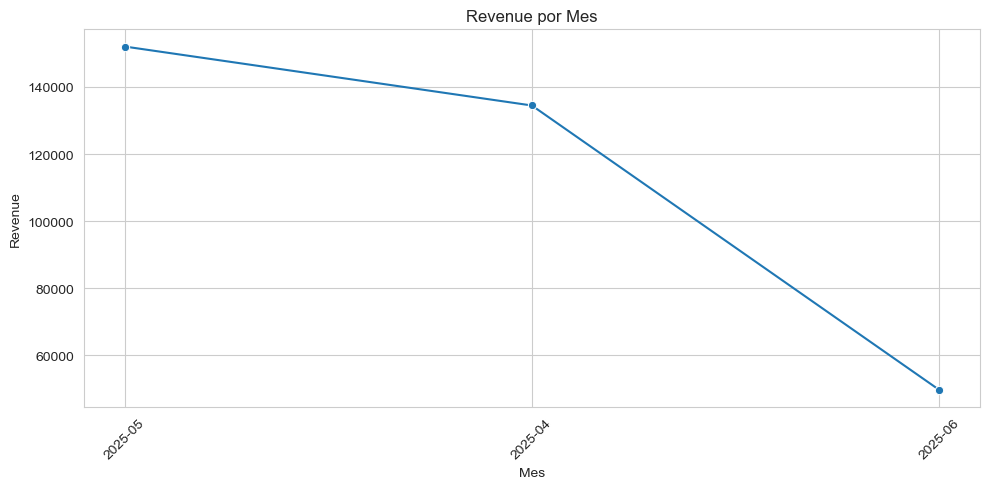

In [29]:
plt.figure(figsize = (10,5))
sns.lineplot(data = monthly_sales, x = "year_month", y = "revenue", marker = "o")
plt.title("Revenue por Mes")
plt.xlabel("Mes")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Insight principal:** Entre los tres meses considerados, Mayo domina con 45.2% del revenue, seguido de cerca por Abril con 40%. En junio los ingresos caen drásticamente a un 14.8%.

**Recomendación:** Analizar estrategias de ventas para Abril-Mayo y estudiar posible efecto de estacionalidad para Junio (inicio del verano en Europa).

**Detalles:**
- Abril-2025: 134,456.64 € (40.0% del total)
- Mayo-2025: 152,027.39 € (45.2% del total)
- Junio-2025: 49,746.39 € (14.8% del total)

#### **6.5. Revenue de Ítems con Descuento vs. No Descuento**

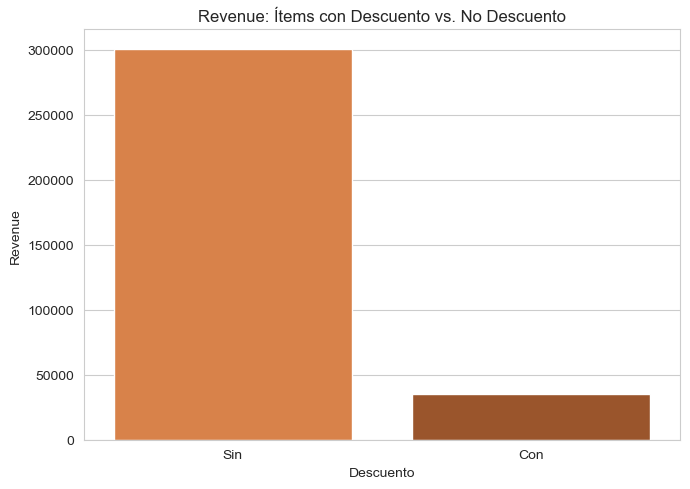

In [30]:
# Mapear True/False a Con/Sin
discount_analysis["item_discounted"] = discount_analysis["item_discounted"].map({True: "Con", False: "Sin"})

plt.figure(figsize = (7,5))
sns.barplot(data = discount_analysis, x = "item_discounted", y = "revenue", hue = "item_discounted", palette = "Oranges_d", legend = False)
plt.title("Revenue: Ítems con Descuento vs. No Descuento")
plt.xlabel("Descuento")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Insight principal:** Existe un mayor revenue por los ítems sin descuento en comparación a los con descuento con un amplio margen (89.4% vs. 10.6% respectivamente).

**Recomendación:** Realizar descuentos en productos específicos y de forma selectiva.

**Detalles:**
- Sin Descuento: 300,663.83 € (89.4% del total)
- Con Descuento: 35,566.59 € (10.6% del total)

#### **6.6. Revenue por Rango Etario**

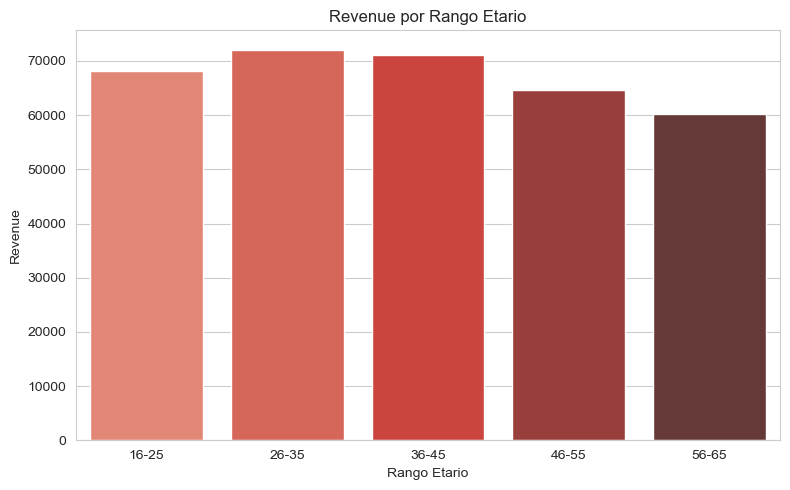

In [31]:
plt.figure(figsize = (8,5))
sns.barplot(data = age_analysis, x = "age_range", y = "revenue", hue = "age_range", palette = "Reds_d", legend = False)
plt.title("Revenue por Rango Etario")
plt.xlabel("Rango Etario")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Insight principal:** El revenue se distribuye de forma bastante uniforme por edad, con mejor desempeño en los segmentos 26-35 (21.4%) y 36-45 (21.2%).

**Recomendación:** Enfocar campañas en rangos que proveen mayor revenue y ajustar la propuesta para mejorar la participación de los grupos con menor aporte.

**Detalles:**
- 16-25: 68201.00 € (20.3% del total)
- 26-35: 72034.86 € (21.4% del total)
- 36-45: 71131.78 € (21.2% del total)
- 46-55: 64715.51 € (19.2% del total)
- 56-65: 60147.27 € (17.9% del total)

### **7. Exportar DataFrame**

In [32]:
# Exportar el DataFrame para trabajarlo con Tableau
e_commerce.to_csv("e_commerce.csv", index = False)